In [26]:
import seaborn as sns
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.dates import DateFormatter
from dateutil.relativedelta import relativedelta
from scipy.optimize import curve_fit

In [2]:
fit_df = pd.read_csv("fit_results.csv")
print(fit_df.columns)
fit_pivot = fit_df.pivot_table(
    index=["Country", "Chain", "Start_date"],
    columns="Parameter",
    values=["Value", "Error"]
)

fit_pivot = fit_pivot.reset_index()
print(fit_pivot.head())

Index(['Country', 'Chain', 'Parameter', 'Value', 'Error', 'Start_date'], dtype='object')
          Country    Chain  Start_date          Error                \
Parameter                                          p0            p1   
0              DE  161+177  2021-08-16  549944.271739  2.157319e+07   
1              DE  194+219  2021-11-29       0.148994  1.759903e-01   
2              DE      215  2022-01-03       0.041153  4.917842e-02   
3              DE  268+322  2022-05-02       0.091671  1.057221e-01   
4              DE  346+433  2022-12-26       0.180068  2.021433e-01   

                                                             Value  \
Parameter             p2        p3        p4        p5          p0   
0          849246.194465  1.334175  0.977721  0.698141  487.796519   
1               0.026555  0.355160  0.369535  0.040537    0.645627   
2               0.005516  0.043074  0.050370  0.015075    1.946782   
3               0.012103  0.330537  0.432520  0.049880    1.291

In [3]:
# Pivot so each chain has all parameters in one row
fit_pivot = fit_df.pivot_table(
    index=['Country', 'Chain', 'Start_date'],
    columns='Parameter',
    values=['Value', 'Error']
).reset_index()

# Flatten multi-level columns
fit_pivot.columns = ['_'.join(filter(None, col)).strip() if isinstance(col, tuple) else col for col in fit_pivot.columns.values]
fit_pivot = fit_pivot.rename(columns={
    'Country_': 'Country',
    'Chain_': 'Chain',
    'Start_date_': 'Start_date'
})

fit_pivot.head()

,Country,Chain,Start_date,Error_p0,Error_p1,Error_p2,Error_p3,Error_p4,Error_p5,Value_p0,Value_p1,Value_p2,Value_p3,Value_p4,Value_p5
0,DE,161+177,2021-08-16,549944.271739,2.157319e+07,849246.194465,1.334175,0.977721,0.698141,487.796519,1736.311952,21.789565,1.978503,19.161916,0.688977
1,DE,194+219,2021-11-29,0.148994,1.759903e-01,0.026555,0.355160,0.369535,0.040537,0.645627,3.269344,0.496431,1.563761,13.146188,0.478324
2,DE,215,2022-01-03,0.041153,4.917842e-02,0.005516,0.043074,0.050370,0.015075,1.946782,6.688723,0.994224,1.023175,21.492414,0.905989
3,DE,268+322,2022-05-02,0.091671,1.057221e-01,0.012103,0.330537,0.432520,0.049880,1.291662,4.810540,1.005985,3.210641,30.892869,0.893645
4,DE,346+433,2022-12-26,0.180068,2.021433e-01,0.008699,NaN,NaN,NaN,2.818898,8.389536,0.968400,NaN,NaN,NaN


In [4]:
# t0 = p1 - 6.91 * p0
# error propagation: sqrt((2.197 * p0_error)^2 + p1_error^2)
fit_pivot['t0'] = fit_pivot['Value_p1'] - 6.91 * fit_pivot['Value_p0']
fit_pivot['t0_error'] = np.sqrt((2.197 * fit_pivot['Error_p0'])**2 + fit_pivot['Error_p1']**2)

fit_pivot[['Country', 'Chain', 't0', 't0_error']].head()

,Country,Chain,t0,t0_error
0,DE,161+177,-1634.361995,2.160700e+07
1,DE,194+219,-1.191939,3.716506e-01
2,DE,215,-6.763542,1.029234e-01
3,DE,268+322,-4.114842,2.274635e-01
4,DE,346+433,-11.089047,4.442627e-01


In [20]:
sequence_dfs = {}
country_list = ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
file = 'Covid_sequences.csv'

for country in country_list:
    fold_to_open = 'data/2020_' + country
    df_sequence = pd.read_csv(fold_to_open + '/' + file)
    df_sequence = df_sequence[['Week', 'N','date_x']]
    df_sequence['country'] = country
    sequence_dfs[country] = df_sequence

#intervals of weeks desired
week_intervals = [(51, 85), (71, 110), (100, 121), (102, 132), (122, 170), (156, 208)]

average_sequence_counts = {}

#computer average number of sequences for country
for country, df_sequence in sequence_dfs.items():
    for i, interval in enumerate(week_intervals, start=1):
        start_week, end_week = interval
        filtered_df = df_sequence[(df_sequence['Week'] >= start_week) & (df_sequence['Week'] <= end_week)]
        average_sequence_count = filtered_df['N'].mean()
        if i not in average_sequence_counts:
            average_sequence_counts[i] = {}
        if country not in average_sequence_counts[i]:
            average_sequence_counts[i][country] = []
        average_sequence_counts[i][country].append(average_sequence_count)

for set_name, country_counts in average_sequence_counts.items():
    print(f"Set {set_name}:")
    for country, counts in country_counts.items():
        print(f"Country: {country}, Number of sequences: {counts}")

Set 1:
Country: SE, Number of sequences: [2915.9142857142856]
Country: DE, Number of sequences: [4741.828571428571]
Country: IT, Number of sequences: [1570.936170212766]
Country: DK, Number of sequences: [3605.3714285714286]
Country: FR, Number of sequences: [2460.169014084507]
Country: SP, Number of sequences: [1958.1714285714286]
Set 2:
Country: SE, Number of sequences: [2462.425]
Country: DE, Number of sequences: [8617.55]
Country: IT, Number of sequences: [2012.607142857143]
Country: DK, Number of sequences: [7075.75]
Country: FR, Number of sequences: [5211.75]
Country: SP, Number of sequences: [2346.275]
Set 3:
Country: SE, Number of sequences: [2678.318181818182]
Country: DE, Number of sequences: [16152.545454545454]
Country: IT, Number of sequences: [2177.730769230769]
Country: DK, Number of sequences: [11917.727272727272]
Country: FR, Number of sequences: [9411.5]
Country: SP, Number of sequences: [2374.181818181818]
Set 4:
Country: SE, Number of sequences: [2070.7419354838707]

In [11]:
#combine t0 values with average sequences per set

#First, we assign a 'Set' number to each chain based on the week interval
set_chain_mapping = {
    1: [47, 52, 50, 53100, 54, 502],
    2: [98118, 161177, 135, 117162],
    3: [194219, 169190, 173204],
    4: [153, 215, 196, 151, 221, 198],
    5: [219271, 268322, 235274305, 216257, 263, 240272297],
    6: [285342, 346433, 295371416, 303378412, 335405, 295364407]
}

#map each chain to a set
def map_chain_to_set(chain):
    for s, chains in set_chain_mapping.items():
        if chain in chains:
            return s
    return np.nan

fit_pivot['Set'] = fit_pivot['Chain'].apply(map_chain_to_set)

#now attach average sequences per set
#we only have one average per country per set
def get_avg_sequences(row):
    set_num = row['Set']
    country = row['Country']
    if set_num in average_sequence_counts and country in average_sequence_counts[set_num]:
        return average_sequence_counts[set_num][country][0]  # take first element
    else:
        return np.nan

fit_pivot['Mean_sequences'] = fit_pivot.apply(get_avg_sequences, axis=1)
fit_plot_df = fit_pivot[['Country', 'Chain', 'Set', 't0', 't0_error', 'Mean_sequences']]
fit_plot_df.head()

,Country,Chain,Set,t0,t0_error,Mean_sequences
0,DE,161177,2.0,-1634.361995,2.160700e+07,8617.550000
1,DE,194219,3.0,-1.191939,3.716506e-01,16152.545455
2,DE,215,4.0,-6.763542,1.029234e-01,14114.419355
3,DE,268322,5.0,-4.114842,2.274635e-01,5474.836735
4,DE,346433,6.0,-11.089047,4.442627e-01,983.943396


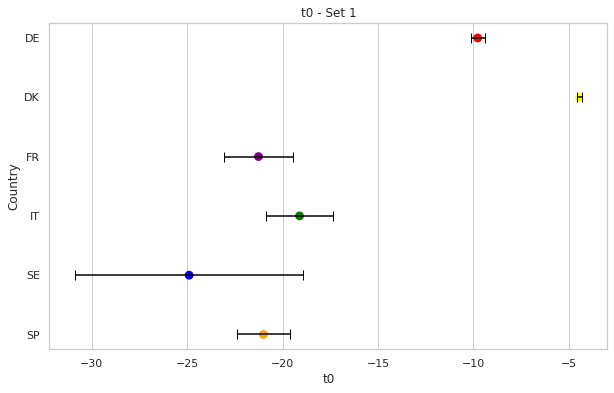

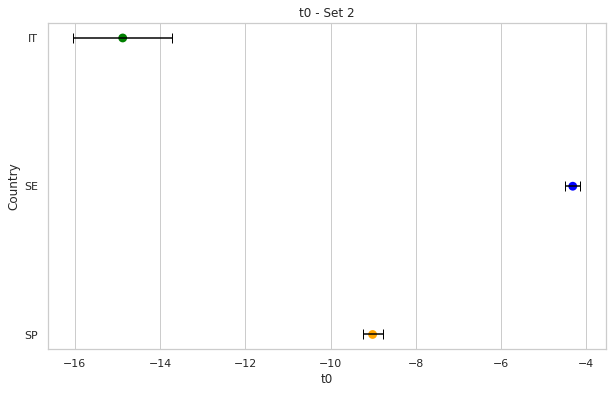

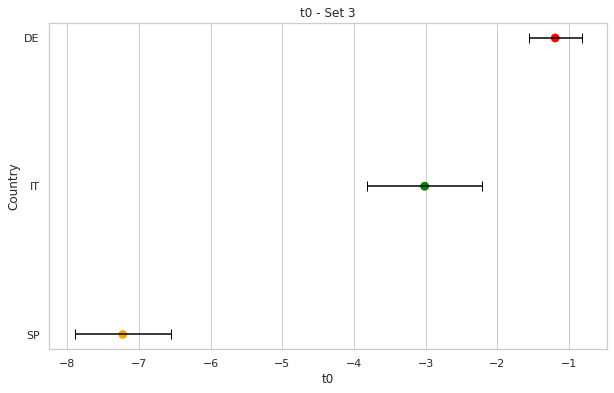

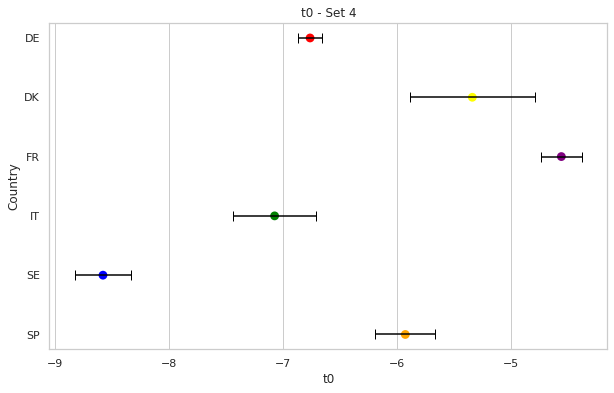

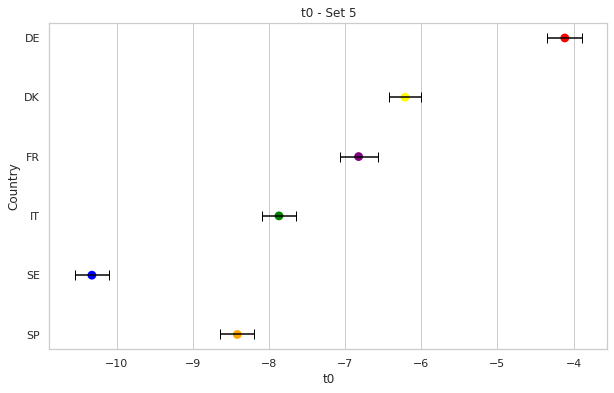

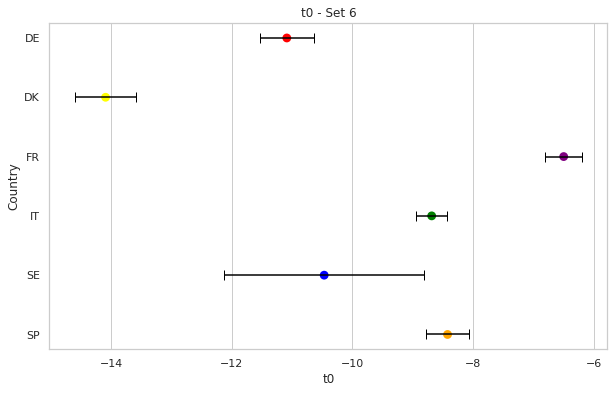

In [16]:
sns.set(style="whitegrid")
country_palette = {'DE': 'red', 'IT': 'green', 'SE': 'blue', 'DK':'yellow', 'FR':'purple', 'SP':'orange'}

#clean Chain column in fit_pivot
def clean_chain(chain):
    """
    Convert chain strings like '161+177' to integer 161177,
    or leave as integer if already numeric.
    """
    if isinstance(chain, str) and '+' in chain:
        return int(chain.replace('+', ''))
    else:
        return int(chain)

fit_pivot['Chain'] = fit_pivot['Chain'].apply(clean_chain)

#define which chains belong to each set
set_chain_mapping = {
    1: [47, 52, 50, 53100, 54, 502],
    2: [98118, 135, 117162],
    3: [194219, 169190, 173204],
    4: [153, 215, 196, 151, 221, 198],
    5: [219271, 268322, 235274305, 216257, 263, 240272297],
    6: [285342, 346433, 295371416, 303378412, 335405, 295364407]
}

#separate param_df for each set
param_dfs = {i: [] for i in range(1, 7)}

#loop through fit_pivot and fill param_dfs based on set
for _, row in fit_pivot.iterrows():
    country = row['Country']
    chain = row['Chain']
    for set_num, chains in set_chain_mapping.items():
        if chain in chains:
            param_dfs[set_num].append([country, chain, 'p0', row['Value_p0'], row['Error_p0']])
            param_dfs[set_num].append([country, chain, 'p1', row['Value_p1'], row['Error_p1']])
            break
            
param_df_dict = {1: param_df_1,2: param_df_2,3: param_df_3,4: param_df_4,5: param_df_5,6: param_df_6}
all_param_df = pd.concat(
    [pd.DataFrame(data, columns=['Country', 'Chain', 'Parameter', 'Value', 'Error']).assign(Set=set_num)
     for set_num, data in param_dfs.items()],
    ignore_index=True
)

all_param_df.head()

def plot_derived_parameter_t0(param_df, title, country_palette, p0_param, p1_param):
    p0_values = param_df[param_df['Parameter'] == p0_param]['Value'].values
    p1_values = param_df[param_df['Parameter'] == p1_param]['Value'].values
    p0_errors = param_df[param_df['Parameter'] == p0_param]['Error'].values
    p1_errors = param_df[param_df['Parameter'] == p1_param]['Error'].values

    derived_values = p1_values - 6.91 * p0_values
    derived_errors = np.sqrt((2.197 * p0_errors)**2 + p1_errors**2)

    plt.figure(figsize=(10, 6))
    sns.pointplot(x=derived_values, y=param_df[param_df['Parameter'] == p1_param]['Country'], join=False, palette=country_palette)
    plt.errorbar(x=derived_values, y=param_df[param_df['Parameter'] == p1_param]['Country'], xerr=derived_errors, fmt='none', ecolor='black', capsize=5)
    plt.xlabel('t0')
    plt.ylabel('Country')
    plt.title(title)
    plt.show()

    return derived_values, derived_errors


t0_values_sets = {}
t0_errors_sets = {}

for set_num, df in param_df_dict.items():
    t0_vals, t0_errs = plot_derived_parameter_t0(df, f't0 - Set {set_num}', country_palette, 'p0', 'p1')
    t0_values_sets[set_num] = t0_vals
    t0_errors_sets[set_num] = t0_errs

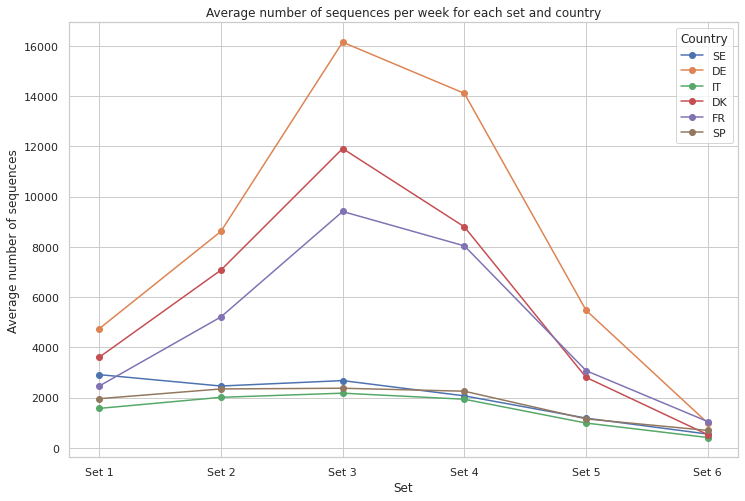

In [18]:
country_list = ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
set_labels = [f'Set {i}' for i in range(1, 7)]

plot_data = {country: [average_sequence_counts[set_num][country][0] for set_num in range(1, 7)]
             for country in country_list}
plt.figure(figsize=(12, 8))
for country, values in plot_data.items():
    plt.plot(set_labels, values, marker='o', label=country)

plt.title('Average number of sequences per week for each set and country')
plt.xlabel('Set')
plt.ylabel('Average number of sequences')
plt.legend(title='Country')
plt.grid(True)
plt.show()

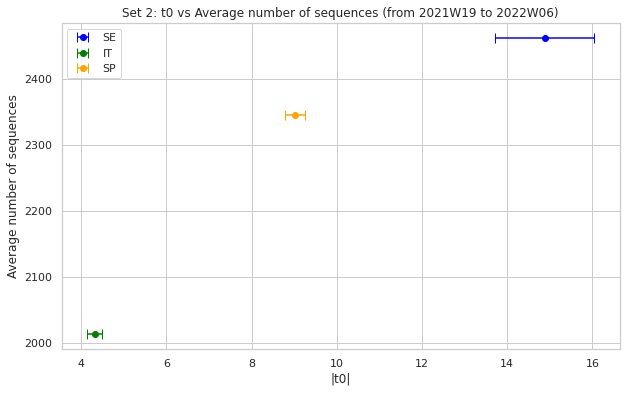

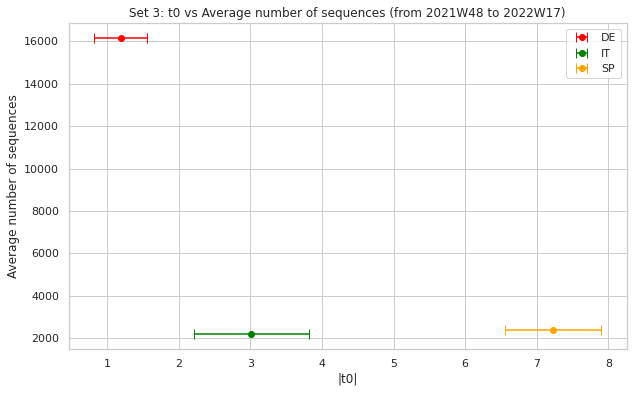

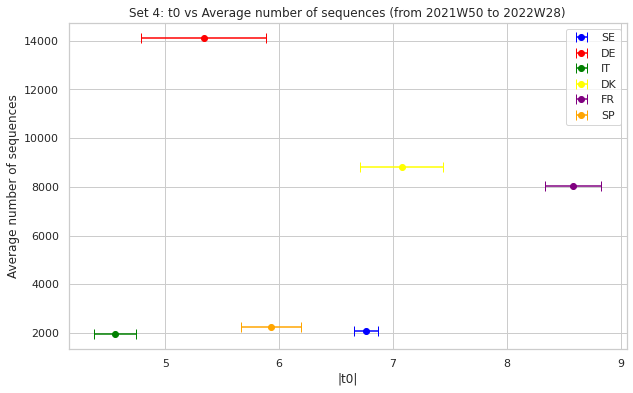

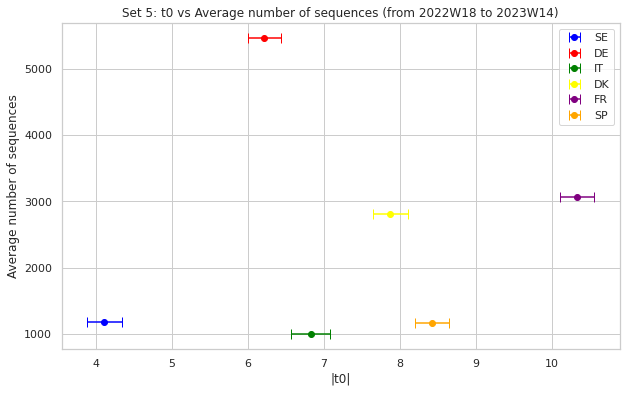

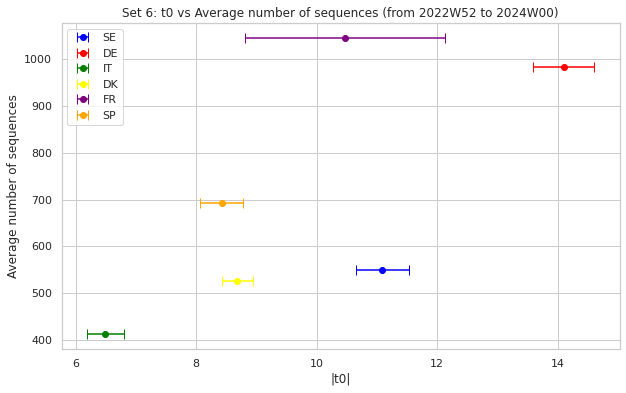

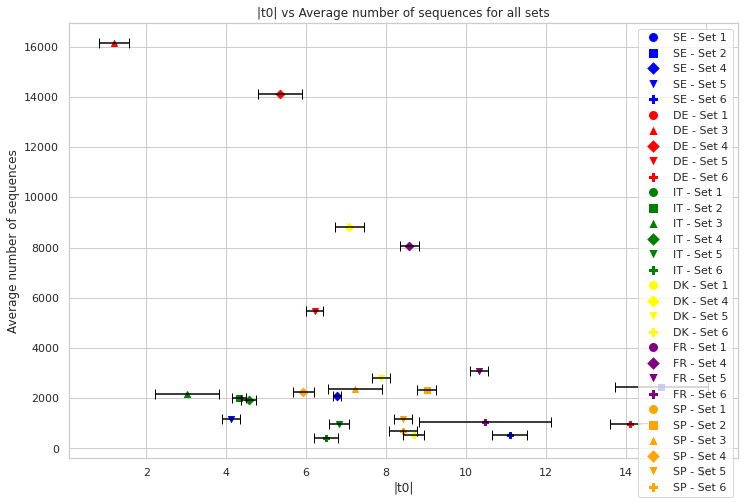

In [25]:
#set intervals for titles
set_intervals = {
    1: "(from 2020W51 to 2021W33)",
    2: "(from 2021W19 to 2022W06)",
    3: "(from 2021W48 to 2022W17)",
    4: "(from 2021W50 to 2022W28)",
    5: "(from 2022W18 to 2023W14)",
    6: "(from 2022W52 to 2024W00)"
}
#define which countries belong to each set
set_country_lists = {
    1: ['SE', 'DE', 'IT', 'DK', 'FR', 'SP'],
    2: ['SE', 'IT', 'SP'],  
    3: ['DE', 'IT', 'SP'],
    4: ['SE','DE', 'IT', 'DK', 'FR', 'SP'], 
    5: ['SE', 'DE', 'IT', 'DK', 'FR', 'SP'],  
    6: ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
}
markers = ['o', 's', '^', 'D', 'v', 'P']  #we choose a unique marker per set

#remove DE 161+177 from t0_values_set_2 
exclude_chains = {
    2: ['DE']  #set 2, country DE, bad fit
}

for i in range(2, 7):
    set_name = f'Set {i}'
    t0_values = np.abs(eval(f"t0_values_set_{i}"))
    t0_errors = eval(f"t0_errors_set_{i}")
    sequences = average_sequence_counts[i]

    plt.figure(figsize=(10, 6))
    
    countries_in_set = [c for c in set_country_lists[i] if c in sequences]

    for count, country in enumerate(countries_in_set):
        if count >= len(t0_values):
            continue
        plt.errorbar(
            t0_values[count],
            sequences[country][0],
            xerr=t0_errors[count],
            fmt='o',
            label=country,
            color=country_palette[country],
            capsize=5
        )

    plt.title(f'{set_name}: t0 vs Average number of sequences {set_intervals[i]}')
    plt.xlabel('|t0|')
    plt.ylabel('Average number of sequences')
    plt.legend()
    plt.grid(True)
    plt.show()

#combined plot for all sets
combined_t0, combined_errors, combined_seq, combined_labels, combined_colors, combined_markers = [], [], [], [], [], []

for i in range(2, 7):
    t0_values = np.abs(eval(f"t0_values_set_{i}"))
    t0_errors = eval(f"t0_errors_set_{i}")
    sequences = average_sequence_counts[i]

    for idx, country in enumerate(set_country_lists[i]):
        if country in sequences:
            combined_t0.append(t0_values[idx])
            combined_errors.append(t0_errors[idx])
            combined_seq.append(sequences[country][0])
            combined_labels.append(f'{country} - Set {i}')
            combined_colors.append(country_palette[country])
            combined_markers.append(markers[i-1])

#plot all sets together
plt.figure(figsize=(12, 8))
for t0, err, seq, label, color, marker in zip(combined_t0, combined_errors, combined_seq, combined_labels, combined_colors, combined_markers):
    plt.scatter(t0, seq, label=label, color=color, marker=marker)
    plt.errorbar(t0, seq, xerr=err, fmt='none', ecolor='black', capsize=5)

plt.title('|t0| vs Average number of sequences for all sets')
plt.xlabel('|t0|')
plt.ylabel('Average number of sequences')

handles = []
for i, country in enumerate(country_list):
    for j in range(1, 7):
        if country in set_country_lists[j]:
            handles.append(plt.Line2D([0], [0], marker=markers[j-1], color='w',
                                      markerfacecolor=country_palette[country], markersize=10,
                                      label=f'{country} - Set {j}'))
unique_labels = []
unique_handles = []
for h in handles:
    if h.get_label() not in unique_labels:
        unique_handles.append(h)
        unique_labels.append(h.get_label())

plt.legend(handles=unique_handles)
plt.grid(True)
plt.show()

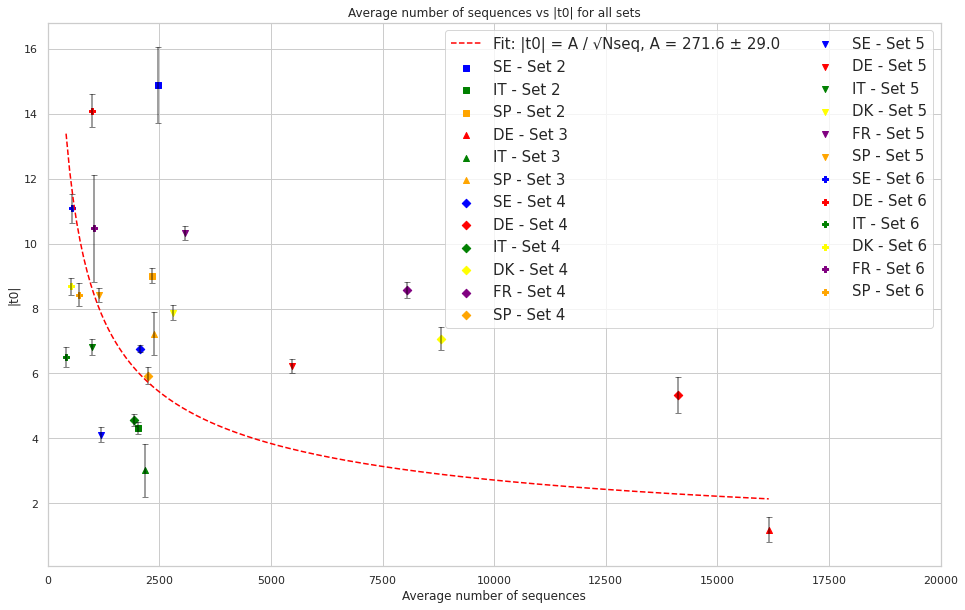

Fit parameter A: 271.5723546638439 ± 28.98388125136047


In [32]:
#prepare combined data
combined_t0, combined_errors, combined_seq, combined_labels, combined_colors, combined_markers = [], [], [], [], [], []

for i in range(2, 7):
    set_name = f'Set {i}'
    t0_values = np.abs(locals()[f't0_values_set_{i}'])
    t0_errors = locals()[f't0_errors_set_{i}']
    sequence_values = average_sequence_counts[i]
    
    #get the countries in the same order as t0_values
    countries_in_set = [c for c in set_country_lists[i] if c not in exclude_chains.get(i, [])]
    
    for idx, country in enumerate(countries_in_set):
        if country in sequence_values:
            combined_t0.append(t0_values[idx])
            combined_errors.append(t0_errors[idx])
            combined_seq.append(sequence_values[country][0])
            combined_labels.append(f'{country} - {set_name}')
            combined_colors.append(country_palette[country])
            combined_markers.append(markers[i-1])

#combined plot
plt.figure(figsize=(16, 10))
for seq, t0, t0_err, lbl, col, mk in zip(combined_seq, combined_t0, combined_errors, combined_labels, combined_colors, combined_markers):
    plt.scatter(seq, t0, label=lbl, color=col, marker=mk)
    plt.errorbar(seq, t0, yerr=t0_err, fmt='none', ecolor='black', alpha=0.5, capsize=3)

plt.title('Average number of sequences vs |t0| for all sets')
plt.xlabel('Average number of sequences')
plt.ylabel('|t0|')
plt.grid(True)

handles = []
for i, country in enumerate(country_list):
    for j in range(1, 7):
        if country in set_country_lists[j]:
            handles.append(
                plt.Line2D([0], [0], marker=markers[j-1], color='w',
                           markerfacecolor=country_palette[country],
                           markersize=10, label=f'{country} - Set {j}')
            )
#remove duplicates
unique_labels = set()
unique_handles = []
for h in handles:
    if h.get_label() not in unique_labels:
        unique_labels.add(h.get_label())
        unique_handles.append(h)

plt.legend(handles=unique_handles, ncol=2, fontsize=12, loc='upper right', frameon=True)
plt.xlim([0, 20000])

#fit: inverse power law
def inverse_power_law(x, A):
    return A / np.sqrt(x)

popt, pcov = curve_fit(inverse_power_law, combined_seq, combined_t0, p0=[15])
error = np.sqrt(np.diag(pcov))

x_fit = np.linspace(min(combined_seq), max(combined_seq), 200)
y_fit = inverse_power_law(x_fit, *popt)
plt.plot(x_fit, y_fit, '--', color='red', label=f'Fit: |t0| = A / √Nseq, A = {popt[0]:.1f} ± {error[0]:.1f}')
plt.legend(ncol=2, fontsize=15, loc='upper right', frameon=True)
plt.savefig("Calibrationcurve.pdf", dpi=300, bbox_inches='tight')
plt.show()
print(f'Fit parameter A: {popt[0]} ± {error[0]}')